# 1. Khai báo thư viện

In [89]:
!pip install googlesearch-python

In [90]:
import numpy as np
import pandas as pd
import ipaddress
import os.path
import requests
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from urllib.parse import urlparse,urlencode
from tld import get_tld
from googlesearch import search
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score, recall_score, precision_score, roc_curve, auc

## 2. Chuẩn bị dữ liệu

In [91]:
file0 = 'legit_url.csv'
file1 = 'verified_online.csv'


## 2.1. Legit URLs

In [92]:
data0 = pd.read_csv(file0)
data0.head()

,url
0,https://www.google.com
1,https://www.youtube.com
2,https://www.facebook.com
3,https://www.baidu.com
4,https://www.wikipedia.org


In [93]:
data0.shape

(345741, 1)

In [94]:
# Lấy ngẫu nhiên 15000 mẫu
legiturl = data0.sample(n=15000, random_state = 12).copy()
legiturl = legiturl.reset_index(drop=True)
legiturl.head()

,url
0,https://www.urbino.net/snippets.cfm?specificSn...
1,https://www.sonypicturesmuseum.com/
2,https://www.particle.physics.ucdavis.edu/bios/...
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...
4,https://www.music.yahoo.com/northern-pikes/


In [95]:
legiturl.shape
legiturl['Label'] = 0
legiturl.head()

,url,Label
0,https://www.urbino.net/snippets.cfm?specificSn...,0
1,https://www.sonypicturesmuseum.com/,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0
4,https://www.music.yahoo.com/northern-pikes/,0


## 2.2. Phishing URLs

In [96]:
data1 = pd.read_csv(file1)
data1.head()

,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,9240799,https://magcustoms.co/wp-content/uploads/2019/...,http://www.phishtank.com/phish_detail.php?phis...,2025-10-14T20:40:57+00:00,yes,2025-10-14T20:52:29+00:00,yes,Other
1,9240795,http://allegrolokalnie.pl-oferta-38752659027.icu/,http://www.phishtank.com/phish_detail.php?phis...,2025-10-14T20:33:00+00:00,yes,2025-10-14T20:42:22+00:00,yes,Allegro
2,9240793,https://suivre-mes-livraison.com/,http://www.phishtank.com/phish_detail.php?phis...,2025-10-14T20:30:15+00:00,yes,2025-10-14T20:42:22+00:00,yes,Other
3,9240792,https://www.suivre-mes-livraison.com/,http://www.phishtank.com/phish_detail.php?phis...,2025-10-14T20:30:05+00:00,yes,2025-10-14T20:42:22+00:00,yes,Other
4,9240789,https://82ff0308-dcde-4707-bb32-67111c795fc0-0...,http://www.phishtank.com/phish_detail.php?phis...,2025-10-14T20:23:34+00:00,yes,2025-10-14T20:42:22+00:00,yes,Other


In [97]:
data1.shape

(49615, 8)

In [98]:
#Lấy ngẫu nhiên 5000 mẫu
phishurl = data1 .sample(n = 15000, random_state = 12).copy()
phishurl = phishurl.reset_index(drop=True)
phishurl.head()

,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,8735501,https://l.ead.me/bfLaYf,http://www.phishtank.com/phish_detail.php?phis...,2024-08-28T21:56:11+00:00,yes,2024-08-28T22:03:53+00:00,yes,Other
1,9230367,https://preview.webflow.com/preview/secure-aut...,http://www.phishtank.com/phish_detail.php?phis...,2025-10-04T11:16:07+00:00,yes,2025-10-04T11:22:18+00:00,yes,Other
2,9235657,https://webmailupdater.glide.page/dl/24b84d,http://www.phishtank.com/phish_detail.php?phis...,2025-10-09T14:14:44+00:00,yes,2025-10-09T14:32:28+00:00,yes,Other
3,8827345,https://sites.google.com/view/undosk/home,http://www.phishtank.com/phish_detail.php?phis...,2024-10-30T15:42:16+00:00,yes,2024-10-30T15:52:22+00:00,yes,Other
4,9175597,http://allegrolokalnie.pi-2842018374923.rest,http://www.phishtank.com/phish_detail.php?phis...,2025-08-06T06:42:01+00:00,yes,2025-08-06T06:51:41+00:00,yes,Allegro


In [99]:
phishurl = phishurl[['url']]
phishurl.shape

(15000, 1)

In [100]:
phishurl['Label'] = 1
phishurl.head()

,url,Label
0,https://l.ead.me/bfLaYf,1
1,https://preview.webflow.com/preview/secure-aut...,1
2,https://webmailupdater.glide.page/dl/24b84d,1
3,https://sites.google.com/view/undosk/home,1
4,http://allegrolokalnie.pi-2842018374923.rest,1


## 2.3. Gộp dữ liệu

In [101]:
urldata = pd.concat([legiturl, phishurl]).reset_index(drop=True)
urldata.shape

(30000, 2)

In [102]:
urldata.head()

,url,Label
0,https://www.urbino.net/snippets.cfm?specificSn...,0
1,https://www.sonypicturesmuseum.com/,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0
4,https://www.music.yahoo.com/northern-pikes/,0


In [103]:
urldata.Label.value_counts()

Label
0    15000
1    15000
Name: count, dtype: int64

In [104]:
urldata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     30000 non-null  object
 1   Label   30000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 468.9+ KB


In [105]:
df = urldata
df.head()

,url,Label
0,https://www.urbino.net/snippets.cfm?specificSn...,0
1,https://www.sonypicturesmuseum.com/,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0
4,https://www.music.yahoo.com/northern-pikes/,0


In [106]:
df.to_csv("urldata.csv", index=False, encoding="utf-8")

In [107]:
# Đếm số dữ liệu trùng lặp
print ('Số dòng bị trùng lặp: ',df.duplicated().sum())

# Xóa dữ liệu trùng lặp
df = df.drop_duplicates()
print ('Số dòng trùng lặp sau khi xử lý: ',df.duplicated().sum())

Số dòng bị trùng lặp:  2
Số dòng trùng lặp sau khi xử lý:  0


# 3. Trích xuất đặc trưng

## 3.1. Domain

In [108]:
# 1. Lấy Domain của URL
def domain (url):
  domain = urlparse(url).netloc
  if re.match(r"^www.", domain):
    domain = domain.replace("www.","")
  return domain

df['Domain'] = df['url'].apply(lambda i: domain(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\4188093903.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Domain'] = df['url'].apply(lambda i: domain(i))


,url,Label,Domain
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com


## 3.2. Kiểm tra địa chỉ IP trong URL

* Nếu URL sử dụng địa chỉ IP thay vì tên miền (ví dụ: http://125.98.3.123) thì có thể đó là phishing.
* Nếu URL có tên miền hợp lệ bình thường (ví dụ: http://www.example.com) thì đó là legit

In [109]:
# 2. Kiểm tra IP
def havingIP(url):
  try:
    ipaddress.ip_address(urlparse(url).netloc)
    return 1 # Phishing
  except:
    return 0 # Legitimate
  
df['Having_IP'] = df['url'].apply(lambda i: havingIP(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\1144028842.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Having_IP'] = df['url'].apply(lambda i: havingIP(i))


,url,Label,Domain,Having_IP
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0


## 3.3. Độ dài URL

Phishing URL thường dài hơn để che giấu những phần đáng ngờ thanh địa chỉ

In [110]:
# 3. Độ dài URL
def URLlength(url):
    # Đo độ dài của URL
    url_length = len(url)

    # Trả về độ dài URL mà không phân loại
    return url_length

df['URL_Length'] = df['url'].apply(lambda i: URLlength(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\1358006165.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['URL_Length'] = df['url'].apply(lambda i: URLlength(i))


,url,Label,Domain,Having_IP,URL_Length
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43


## 3.4. Rút gọn URL

Một vài URL sẽ sử dụng phương pháp rút gọn tạo ra những URL mới ngắn hơn để dễ dàng chia sẻ. Tuy nhiên, đây cũng là cách các PhisURL "núp bóng". Do đó:
* Nếu URL rút gọn (ví dụ: bit.ly, goo.gl, tinyurl, v.v.) -> PhishURL
* Nếu URL không rút gọn -> LegitURL

In [111]:
shortening_services = r"bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|" \
                      r"yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|" \
                      r"short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|" \
                      r"doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|db\.tt|" \
                      r"qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|q\.gs|is\.gd|" \
                      r"po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|x\.co|" \
                      r"prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|" \
                      r"tr\.im|link\.zip\.net"

In [112]:
# 4. URL rút gọn
def tinyURL(url):
    match = re.search(shortening_services, url)  # Tìm kiếm nếu URL có dịch vụ rút gọn
    if match:
        return 1  # Phishing
    else:
        return 0  # Legitimate
    
df ['Tiny_URL'] = df['url'].apply(lambda i :tinyURL(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\1214875243.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df ['Tiny_URL'] = df['url'].apply(lambda i :tinyURL(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0


## 3.5. Độ dài của TLD

TLD (Top-Level Domain) là phần cuối cùng của một tên miền trong hệ thống phân cấp của DNS (Domain Name System). Ví dụ, trong URL www.example.com, phần .com là TLD. Do đó:
* Nếu độ dài của TLD lớn hơn 3 ký tự -> PhishURL
* Nếu độ dài của TLD nhở hơn hoặc bằng 3 ký tự -> LegitURL

In [113]:
# 5. Độ dài TLD
def tldLength(url):
  try:
      # Lấy TLD của URL
      tld = get_tld(url, fail_silently=True)

      # Nếu TLD tồn tại, trả về độ dài của TLD
      if tld:
          return len(tld)  # Đếm độ dài TLD

      else:
          return 0  # Nếu không có TLD, trả về 0

  except:
      return 0  # Phản hồi 0 nếu có lỗi trong việc lấy TLD
  
df['TLD_Length'] = df['url'].apply(lambda i : tldLength(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\2194153510.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TLD_Length'] = df['url'].apply(lambda i : tldLength(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3


## 3.6. Số ký tự chữ số trong URL




URL có chứa nhiều ký tự số thì có có thể là PhishURL

In [114]:
# 6. Đếm số lượng ký tự số có trong URL
def digitCount(url):
    # Đếm số lượng chữ số trong URL
    count = 0
    for char in url:
        if char.isnumeric():
            count += 1
    return count

df['Digit_Count'] = df['url'].apply(lambda i : digitCount(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\3194892924.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Digit_Count'] = df['url'].apply(lambda i : digitCount(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0


## 3.7. Số chữ cái trong URL

PhishURL thường có nhiều chữ cái hơn để che giấu tên miền đáng ngờ

In [115]:
# 7. Đếm số lượng chữ cái có trong URL
def letterCount(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters = letters + 1
    return letters

df['Letter_Count'] = df['url'].apply(lambda i : letterCount(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\2632350526.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Letter_Count'] = df['url'].apply(lambda i : letterCount(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34


## 3.8. Số lượng dấu '.'

In [116]:
# 8. Đếm số dấu '.'
def dotCount(url):
    return url.count('.')

df['Dot_Count'] = df['url'].apply(lambda i : dotCount(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\798438741.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Dot_Count'] = df['url'].apply(lambda i : dotCount(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3


## 3.9. Số lượng 'www'

In [117]:
# 9. Đếm 'www'
def wwwCount(url):
    return url.count('www')

df['www_Count'] = df['url'].apply(lambda i : wwwCount(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\2155934223.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['www_Count'] = df['url'].apply(lambda i : wwwCount(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1


## 3.10. Số lượng '@'

In [118]:
#10. Đếm số @ trong URL
def atSignCount(url):
    return url.count('@')

df['At_Count'] = df['url'].apply(lambda i : atSignCount(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\3752793517.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['At_Count'] = df['url'].apply(lambda i : atSignCount(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1,0
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1,0
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1,0


## 3.11. Số lượng '-'

In [119]:
# 11. Đếm '-' trong domain URL
def hyphenCount(url):
    return url.count('-')

df['Hyphen_Count'] = df['url'].apply(lambda i : hyphenCount(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\596659175.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hyphen_Count'] = df['url'].apply(lambda i : hyphenCount(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count,Hyphen_Count
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1,0,0
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1,0,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1,0,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1,0,0
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1,0,1


## 3.12. Số lượng dấu %

In [120]:
# 12. Đếm '%'
def perCount(url):
    return url.count('%')

df['Per_Count'] = df['url'].apply(lambda i : perCount(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\3257789319.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Per_Count'] = df['url'].apply(lambda i : perCount(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count,Hyphen_Count,Per_Count
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1,0,0,0
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1,0,0,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1,0,0,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1,0,0,0
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1,0,1,0


## 3.13. Số lượng dấu '?'

In [121]:
# 13. Đếm '?'
def quesCount(url):
    return url.count('?')

df['Ques_Count'] = df['url'].apply(lambda i : quesCount(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\3536175699.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ques_Count'] = df['url'].apply(lambda i : quesCount(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count,Hyphen_Count,Per_Count,Ques_Count
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1,0,0,0,1
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1,0,0,0,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1,0,0,0,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1,0,0,0,0
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1,0,1,0,0


## 3.14. Số lượng dấu '='

In [122]:
# 14. Đếm dâu '='
def equalCount(url):
    return url.count('=')

df['Equal_Count'] = df['url'].apply(lambda i : equalCount(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\1997331968.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Equal_Count'] = df['url'].apply(lambda i : equalCount(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count,Hyphen_Count,Per_Count,Ques_Count,Equal_Count
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1,0,0,0,1,1
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1,0,0,0,0,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1,0,0,0,0,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1,0,0,0,0,0
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1,0,1,0,0,0


## 3.15. Vị trí của dấu '//'

In [123]:
# 15. Số lượng dấu '//'
def redirection(url):
    pos = url.rfind('//')

    # Kiểm tra vị trí của '//' trong URL
    if pos > 6: 
        if pos > 7:
            return 1  
        else:
            return 0  
    else:
        return 0 

df['Redirection'] = df['url'].apply(lambda i : redirection(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\1153898683.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Redirection'] = df['url'].apply(lambda i : redirection(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count,Hyphen_Count,Per_Count,Ques_Count,Equal_Count,Redirection
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1,0,0,0,1,1,0
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1,0,0,0,0,0,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1,0,0,0,0,0,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1,0,0,0,0,0,0
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1,0,1,0,0,0,0


## 3.16. Độ sâu của URL

Các URL hợp lệ thường có ít thư mục con, trong khi đó các URL lừa đảo sẽ có nhiều hơn

In [124]:
def getDepth(url):
    s = urlparse(url).path.split('/')
    depth = 0
    for j in range(len(s)):
        if len(s[j]) != 0:
            depth = depth+1
    return depth

df['Depth'] = df['url'].apply(lambda i : getDepth(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\3838785832.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Depth'] = df['url'].apply(lambda i : getDepth(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count,Hyphen_Count,Per_Count,Ques_Count,Equal_Count,Redirection,Depth
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1,0,0,0,1,1,0,1
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1,0,0,0,0,0,0,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1,0,0,0,0,0,0,2
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1,0,0,0,0,0,0,2
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1,0,1,0,0,0,0,1


## 3.18. Kiểm tra "http/https" trong Domain

Các web lừa đảo thường sử dụng 'https' hoặc 'http' trong domain để đánh lừa người dùng. Do đó:
* Nếu domain URL có chứa 'http' hoặc 'https' -> PhishURL
* Nếu domain URL không có -> LegitURL

In [125]:
# 18. Kiểm tra "http/https"
def httphttpsDomain(url):
    domain = urlparse(url).netloc

    if 'http' in domain or 'https' in domain:
        return 1  # Phishing
    else:
        return 0  # Legit

df['httphttpsDomain'] = df['url'].apply(lambda i : httphttpsDomain(i))
df.head()


C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\2242006072.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['httphttpsDomain'] = df['url'].apply(lambda i : httphttpsDomain(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count,Hyphen_Count,Per_Count,Ques_Count,Equal_Count,Redirection,Depth,httphttpsDomain
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1,0,0,0,1,1,0,1,0
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1,0,0,0,0,0,0,0,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1,0,0,0,0,0,0,2,0
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1,0,0,0,0,0,0,2,0
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1,0,1,0,0,0,0,1,0


## 3.19. Độ dài tên của thư mục đầu tiên

In [126]:
# 19. Độ dài của thư mục đầu tiên
def fdLength(url):
    urlpath = urlparse(url).path
    try:
        return len(urlpath.split('/')[1])
    except:
        return 0
    
df['FD_Length'] = df['url'].apply(lambda i : fdLength(i))
df.head()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\4086557122.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FD_Length'] = df['url'].apply(lambda i : fdLength(i))


,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count,Hyphen_Count,Per_Count,Ques_Count,Equal_Count,Redirection,Depth,httphttpsDomain,FD_Length
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1,0,0,0,1,1,0,1,0,12
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1,0,0,0,0,0,0,0,0,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1,0,0,0,0,0,0,2,0,4
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1,0,0,0,0,0,0,2,0,4
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1,0,1,0,0,0,0,1,0,14


# 4. Trực quan hóa dữ liệu

In [127]:
df.shape

(29998, 20)

In [128]:
df.head()

,url,Label,Domain,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count,Hyphen_Count,Per_Count,Ques_Count,Equal_Count,Redirection,Depth,httphttpsDomain,FD_Length
0,https://www.urbino.net/snippets.cfm?specificSn...,0,urbino.net,0,106,0,3,1,85,3,1,0,0,0,1,1,0,1,0,12
1,https://www.sonypicturesmuseum.com/,0,sonypicturesmuseum.com,0,35,0,3,0,29,2,1,0,0,0,0,0,0,0,0,0
2,https://www.particle.physics.ucdavis.edu/bios/...,0,particle.physics.ucdavis.edu,0,58,0,3,0,48,5,1,0,0,0,0,0,0,2,0,4
3,https://www.en.wikipedia.org/wiki/Attack_of_Th...,0,en.wikipedia.org,0,63,0,3,0,51,3,1,0,0,0,0,0,0,2,0,4
4,https://www.music.yahoo.com/northern-pikes/,0,music.yahoo.com,0,43,0,3,0,34,3,1,0,1,0,0,0,0,1,0,14


In [129]:
df. info()

<class 'pandas.core.frame.DataFrame'>
Index: 29998 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   url              29998 non-null  object
 1   Label            29998 non-null  int64 
 2   Domain           29998 non-null  object
 3   Having_IP        29998 non-null  int64 
 4   URL_Length       29998 non-null  int64 
 5   Tiny_URL         29998 non-null  int64 
 6   TLD_Length       29998 non-null  int64 
 7   Digit_Count      29998 non-null  int64 
 8   Letter_Count     29998 non-null  int64 
 9   Dot_Count        29998 non-null  int64 
 10  www_Count        29998 non-null  int64 
 11  At_Count         29998 non-null  int64 
 12  Hyphen_Count     29998 non-null  int64 
 13  Per_Count        29998 non-null  int64 
 14  Ques_Count       29998 non-null  int64 
 15  Equal_Count      29998 non-null  int64 
 16  Redirection      29998 non-null  int64 
 17  Depth            29998 non-null  int

## 4.1. Đơn biến

### 4.1.1. Binary cols

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\663623746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Having_IP', data = df, palette='Set2')


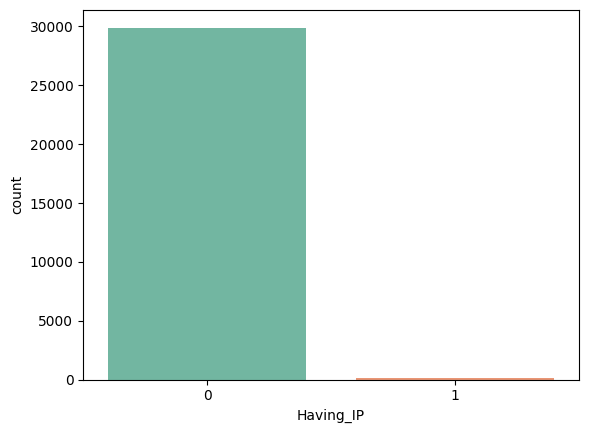

In [130]:
# Having_IP
sns.countplot(x='Having_IP', data = df, palette='Set2')
plt.show()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\992629886.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Tiny_URL', data = df, palette='Set2')


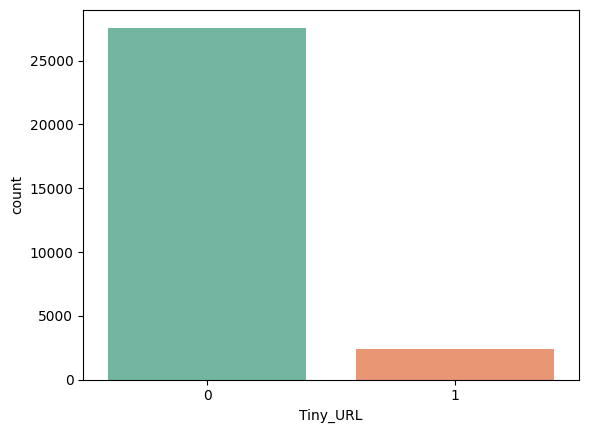

In [131]:
# Tiny_URL 
sns.countplot(x='Tiny_URL', data = df, palette='Set2')
plt.show()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\2053339319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='httphttpsDomain', data=df, palette='Set2')


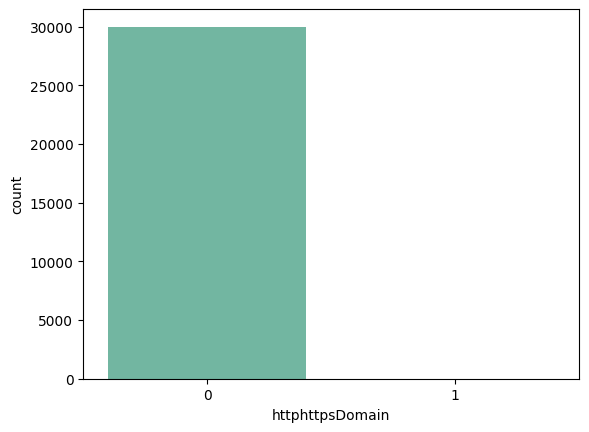

In [132]:
# Google Index
sns.countplot(x='httphttpsDomain', data=df, palette='Set2')
plt.show()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\3738123989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Redirection', data=df, palette='Set2')


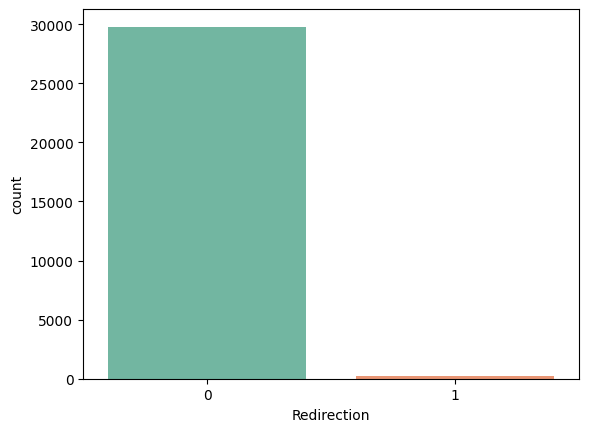

In [133]:
# redirection
sns.countplot(x='Redirection', data=df, palette='Set2')
plt.show()

C:\Users\lengo\AppData\Local\Temp\ipykernel_6808\2303654282.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette='Set2')


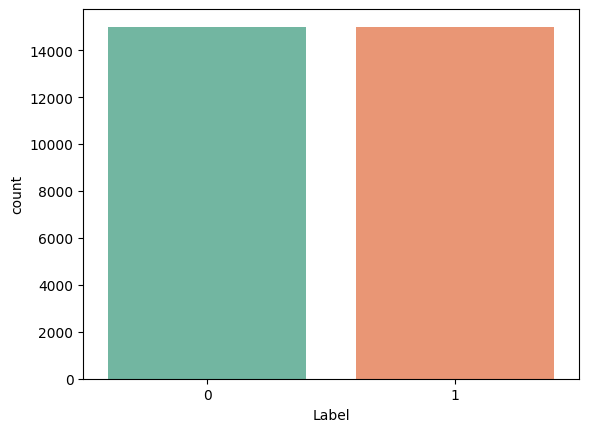

In [134]:
# Label
sns.countplot(x='Label', data=df, palette='Set2')
plt.show()

### 4.1.2. Univariate cols

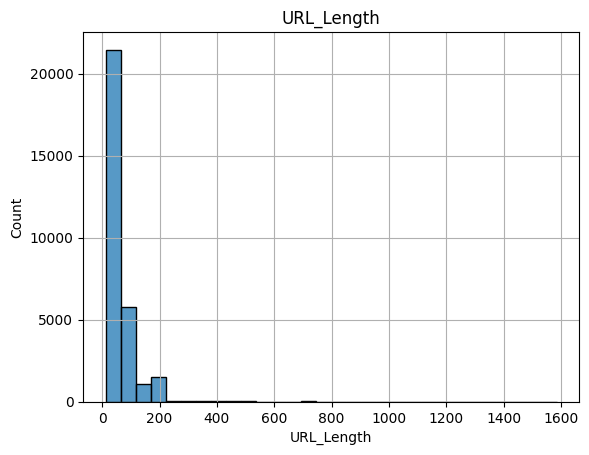

In [135]:
# URL_Length
sns.histplot(df['URL_Length'], bins = 30)
plt.title('URL_Length')
plt.grid(True)
plt.show()

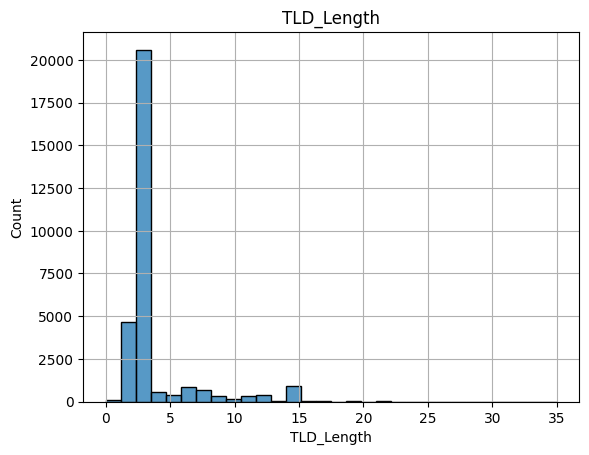

In [136]:
# TLD_Length
sns.histplot(df['TLD_Length'], bins = 30)
plt.title('TLD_Length')
plt.grid(True)
plt.show()

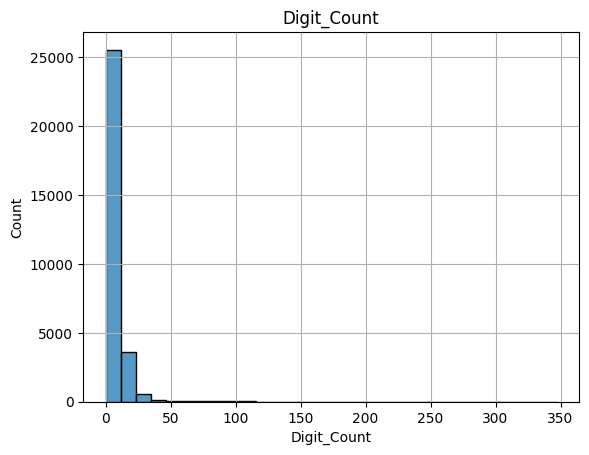

In [137]:
# Digit_Count
sns.histplot(df['Digit_Count'], bins = 30)
plt.title('Digit_Count')
plt.grid(True)
plt.show()

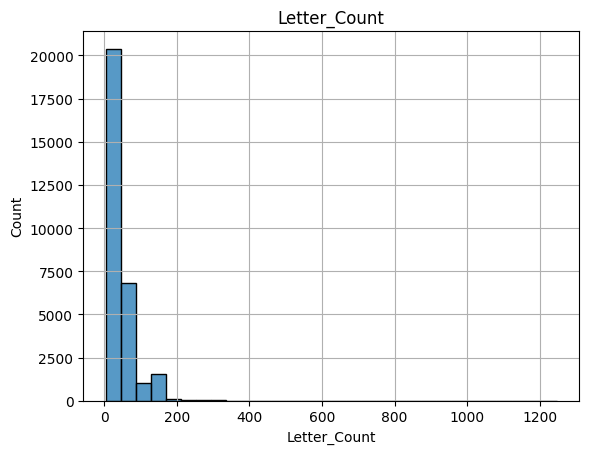

In [138]:
# Letter_Count
sns.histplot(df['Letter_Count'], bins = 30)
plt.title('Letter_Count')
plt.grid(True)
plt.show()

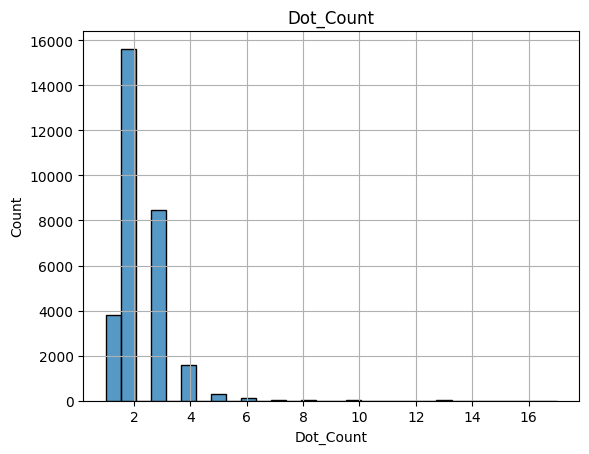

In [139]:
# Dot_Count
sns.histplot(df['Dot_Count'], bins = 30)
plt.title('Dot_Count')
plt.grid(True)
plt.show()

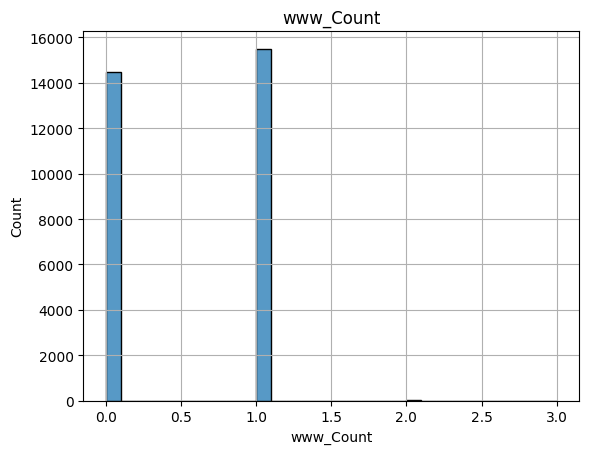

In [140]:
# www_Count
sns.histplot(df['www_Count'], bins = 30)
plt.title('www_Count')
plt.grid(True)
plt.show()

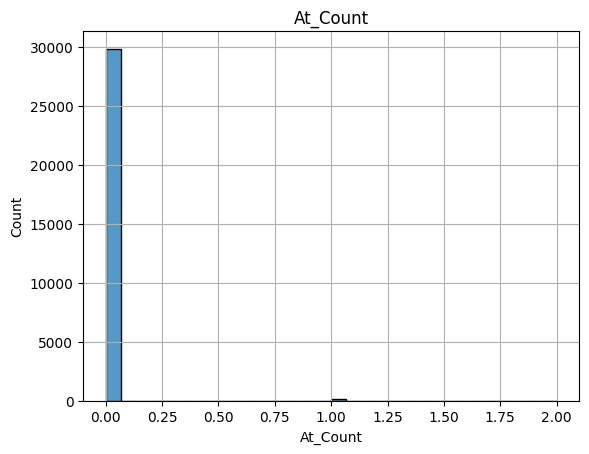

In [141]:
# At_Count
sns.histplot(df['At_Count'], bins = 30)
plt.title('At_Count')
plt.grid(True)
plt.show()

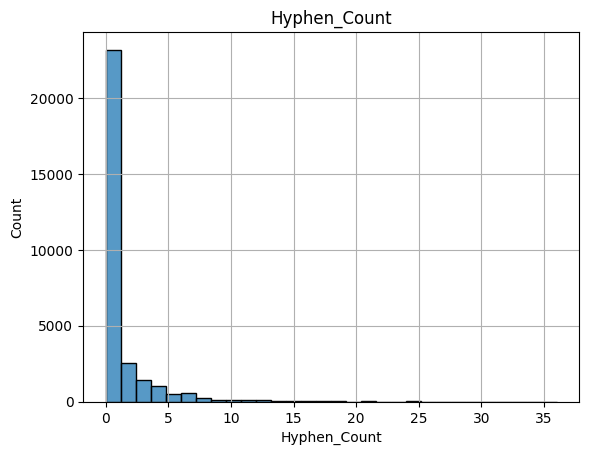

In [142]:
# Hyphen_Count
sns.histplot(df['Hyphen_Count'], bins = 30)
plt.title('Hyphen_Count')
plt.grid(True)
plt.show()

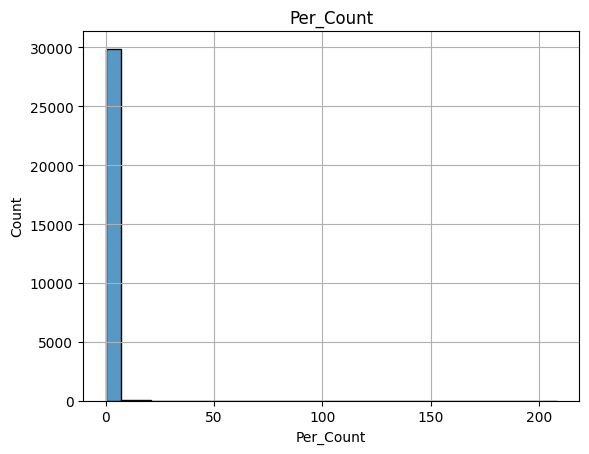

In [143]:
# Per_Count
sns.histplot(df['Per_Count'], bins = 30)
plt.grid(True)
plt.title('Per_Count')
plt.grid(True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

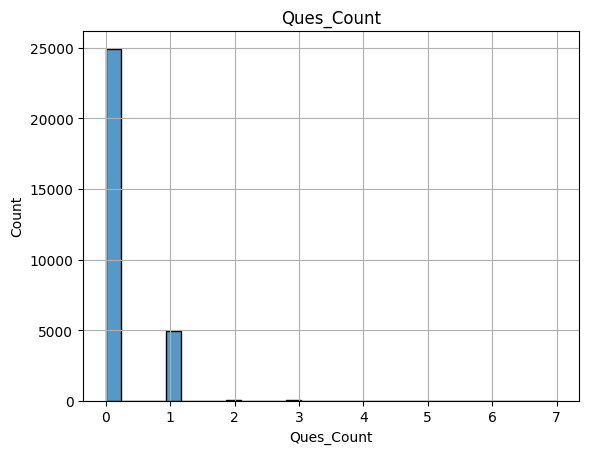

In [144]:
# Ques_Count
sns.histplot(df['Ques_Count'], bins = 30)
plt.title('Ques_Count')
plt.grid(True)
plt.show

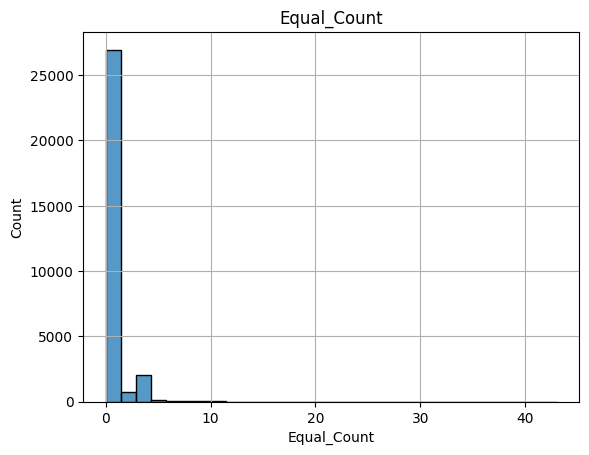

In [145]:
# Equal_Count
sns.histplot(df['Equal_Count'], bins = 30)
plt.title('Equal_Count')
plt.grid(True)
plt.show()

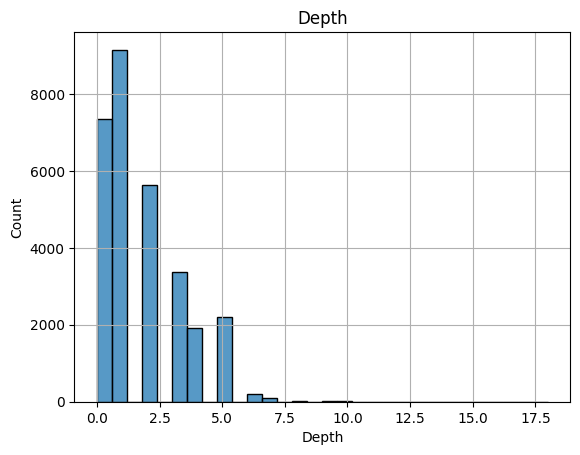

In [146]:
# Depth
sns.histplot(df['Depth'], bins = 30)
plt.title('Depth')
plt.grid(True)
plt.show()

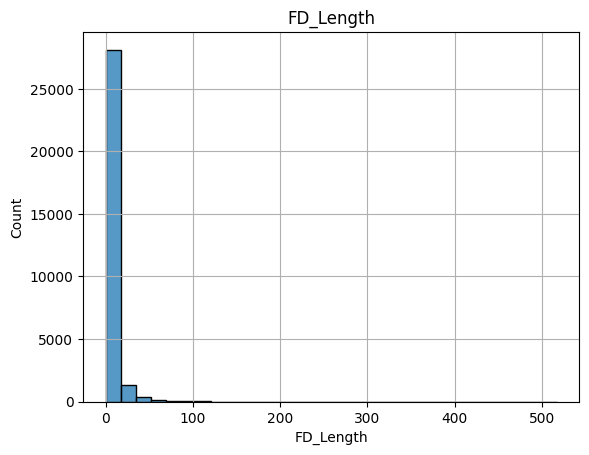

In [147]:
# FD_Length
sns.histplot(df['FD_Length'], bins = 30)
plt.title('FD_Length')
plt.grid(True)
plt.show()

Một vài đặc trưng chỉ có một giá trị, không có ý nghĩa để xây dựng mô hình dự đoán => drop

In [148]:
df = df.drop(['url', 'Domain', 'httphttpsDomain'], axis = 1)
df.head()

,Label,Having_IP,URL_Length,Tiny_URL,TLD_Length,Digit_Count,Letter_Count,Dot_Count,www_Count,At_Count,Hyphen_Count,Per_Count,Ques_Count,Equal_Count,Redirection,Depth,FD_Length
0,0,0,106,0,3,1,85,3,1,0,0,0,1,1,0,1,12
1,0,0,35,0,3,0,29,2,1,0,0,0,0,0,0,0,0
2,0,0,58,0,3,0,48,5,1,0,0,0,0,0,0,2,4
3,0,0,63,0,3,0,51,3,1,0,0,0,0,0,0,2,4
4,0,0,43,0,3,0,34,3,1,0,1,0,0,0,0,1,14


## 4.2. Đa biến

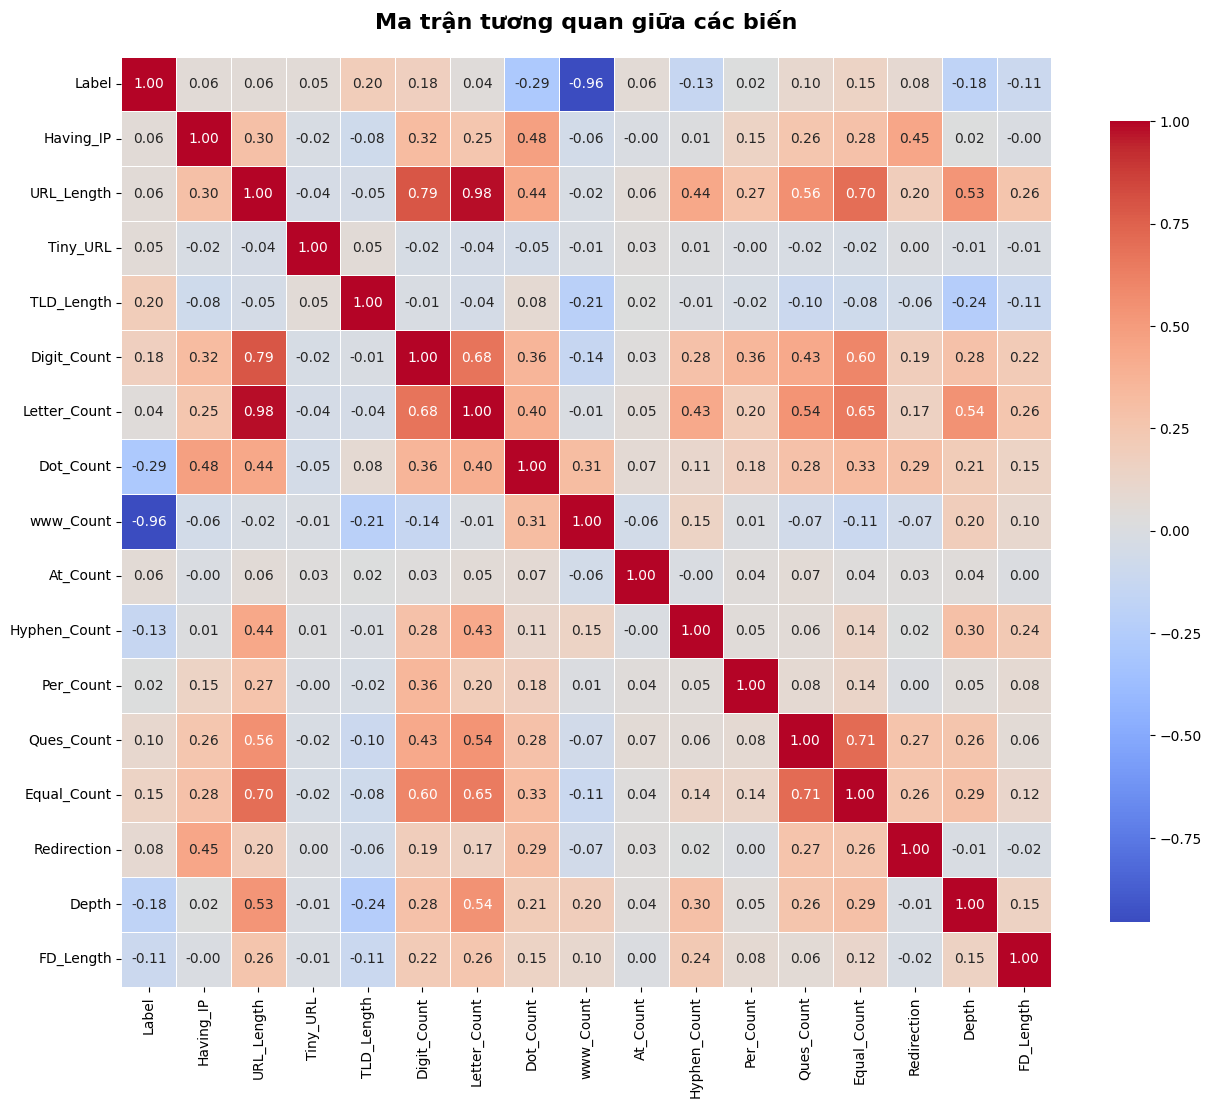

In [149]:
plt.figure(figsize=(15,13))

sns.heatmap(
    df.corr(),                 # ma trận tương quan
    annot=True,                # hiển thị số
    fmt=".2f",                 # 2 chữ số thập phân
    cmap="coolwarm",           # bảng màu (có thể thử 'YlGnBu', 'viridis', 'magma', v.v.)
    linewidths=0.5,            # đường ngăn giữa các ô
    cbar_kws={'shrink': 0.8},  # thu nhỏ thanh màu
    square=True                # ô vuông đều
)

plt.title("Ma trận tương quan giữa các biến", fontsize=16, fontweight='bold', pad=20)
plt.show()

In [150]:
df = df.drop(['Letter_Count', 'URL_Length', 'www_Count', 'Ques_Count'], axis=1)

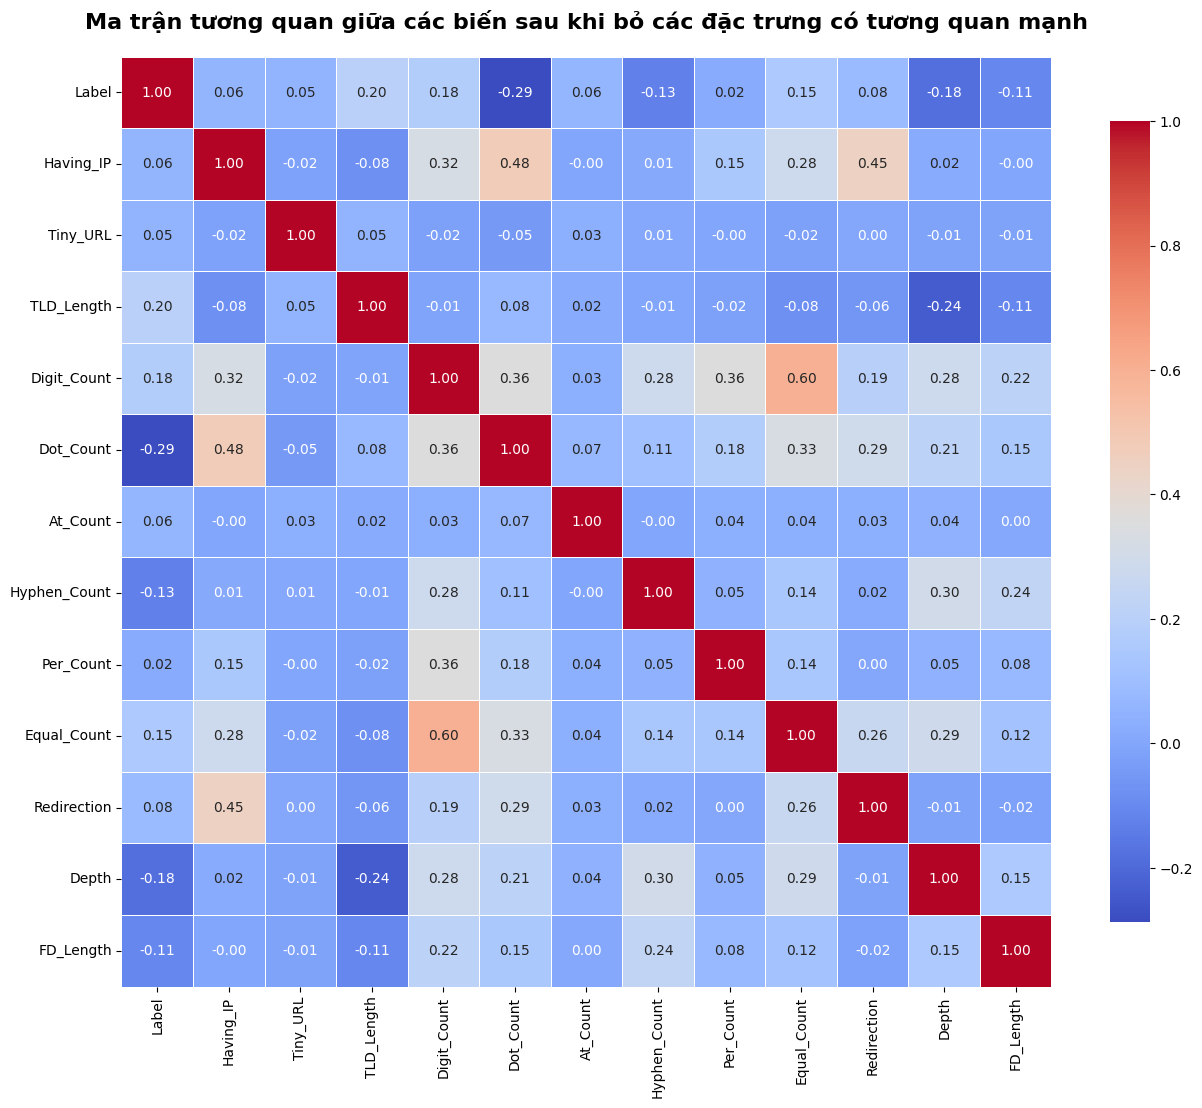

In [151]:
plt.figure(figsize=(15,13))

sns.heatmap(
    df.corr(),                 # ma trận tương quan
    annot=True,                # hiển thị số
    fmt=".2f",                 # 2 chữ số thập phân
    cmap="coolwarm",           # bảng màu (có thể thử 'YlGnBu', 'viridis', 'magma', v.v.)
    linewidths=0.5,            # đường ngăn giữa các ô
    cbar_kws={'shrink': 0.8},  # thu nhỏ thanh màu
    square=True                # ô vuông đều
)

plt.title("Ma trận tương quan giữa các biến sau khi bỏ các đặc trưng có tương quan mạnh", fontsize=16, fontweight='bold', pad=20)
plt.show()

In [152]:
df.shape

(29998, 13)

In [153]:
df.columns

Index(['Label', 'Having_IP', 'Tiny_URL', 'TLD_Length', 'Digit_Count',
       'Dot_Count', 'At_Count', 'Hyphen_Count', 'Per_Count', 'Equal_Count',
       'Redirection', 'Depth', 'FD_Length'],
      dtype='object')

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29998 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Label         29998 non-null  int64
 1   Having_IP     29998 non-null  int64
 2   Tiny_URL      29998 non-null  int64
 3   TLD_Length    29998 non-null  int64
 4   Digit_Count   29998 non-null  int64
 5   Dot_Count     29998 non-null  int64
 6   At_Count      29998 non-null  int64
 7   Hyphen_Count  29998 non-null  int64
 8   Per_Count     29998 non-null  int64
 9   Equal_Count   29998 non-null  int64
 10  Redirection   29998 non-null  int64
 11  Depth         29998 non-null  int64
 12  FD_Length     29998 non-null  int64
dtypes: int64(13)
memory usage: 3.2 MB


# 5. Áp dụng mô hình

In [155]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [156]:
x = df.drop(columns=['Label'])
y = df['Label']
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=42)

## 5.1. KNN

In [157]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

Độ chính xác của mô hình KNN:  0.8898888888888888
Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.91      0.87      0.89      4558
           1       0.87      0.91      0.89      4442

    accuracy                           0.89      9000
   macro avg       0.89      0.89      0.89      9000
weighted avg       0.89      0.89      0.89      9000



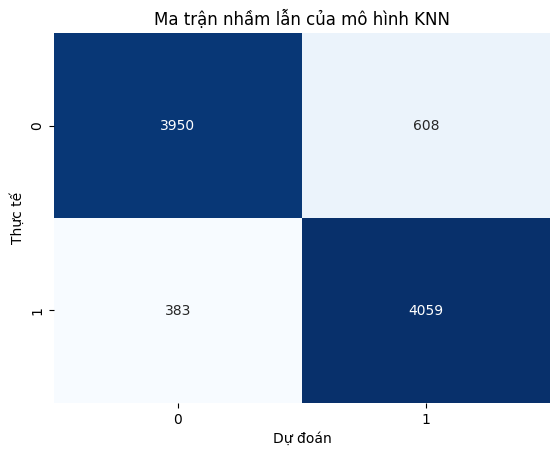

In [158]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Độ chính xác của mô hình KNN: ", accuracy_knn)
print("Báo cáo phân loại:\n", classification_report(y_test, y_pred_knn))
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(conf_matrix_knn, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.title('Ma trận nhầm lẫn của mô hình KNN')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

## 5.2. Decision Tree

In [159]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

Độ chính xác của mô hình Decision Tree:  0.9146666666666666
Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      4558
           1       0.93      0.89      0.91      4442

    accuracy                           0.91      9000
   macro avg       0.92      0.91      0.91      9000
weighted avg       0.92      0.91      0.91      9000



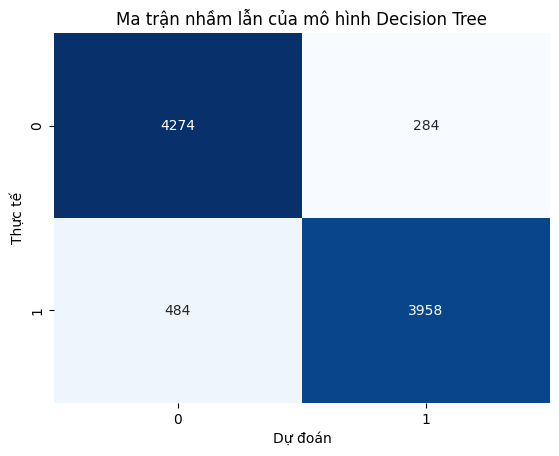

In [160]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Độ chính xác của mô hình Decision Tree: ", accuracy_dt)
print("Báo cáo phân loại:\n", classification_report(y_test, y_pred_dt))
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(conf_matrix_dt, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.title('Ma trận nhầm lẫn của mô hình Decision Tree')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

## 5.3. Random Forest

In [161]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

Độ chính xác của mô hình Random Forest:  0.9257777777777778
Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93      4558
           1       0.95      0.90      0.92      4442

    accuracy                           0.93      9000
   macro avg       0.93      0.93      0.93      9000
weighted avg       0.93      0.93      0.93      9000



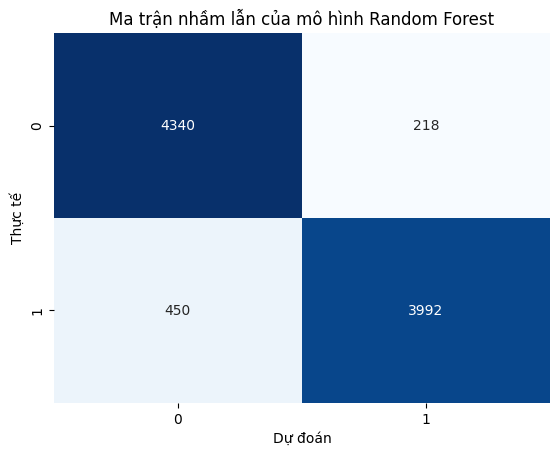

In [162]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Độ chính xác của mô hình Random Forest: ", accuracy_rf)
print("Báo cáo phân loại:\n", classification_report(y_test, y_pred_rf))
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)


sns.heatmap(conf_matrix_rf, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.title('Ma trận nhầm lẫn của mô hình Random Forest')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

## 5.4. Logistic Regression

In [163]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

c:\Users\lengo\Downloads\Python\python-hoctap\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Độ chính xác của mô hình Logistic Regression:  0.7895555555555556
Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79      4558
           1       0.78      0.81      0.79      4442

    accuracy                           0.79      9000
   macro avg       0.79      0.79      0.79      9000
weighted avg       0.79      0.79      0.79      9000



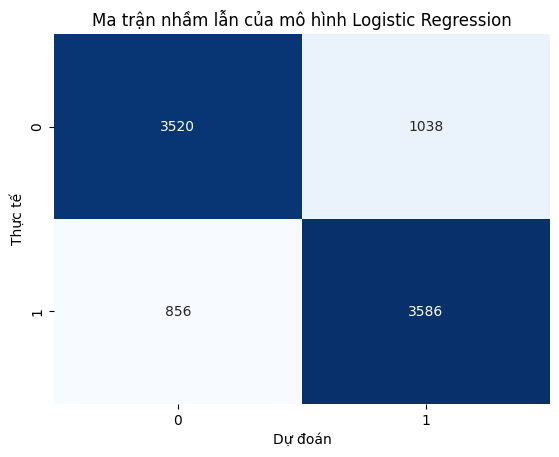

In [164]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Độ chính xác của mô hình Logistic Regression: ", accuracy_lr)
print("Báo cáo phân loại:\n", classification_report(y_test, y_pred_lr))
conf_matrix_lr= confusion_matrix(y_test, y_pred_lr)

sns.heatmap(conf_matrix_lr, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.title('Ma trận nhầm lẫn của mô hình Logistic Regression')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

## 5.5. Mô hình XGBoost

In [165]:
xgb = XGBClassifier(learning_rate=0.4,max_depth=7)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

Độ chính xác của mô hình XGBoost:  0.9263333333333333
Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93      4558
           1       0.95      0.90      0.92      4442

    accuracy                           0.93      9000
   macro avg       0.93      0.93      0.93      9000
weighted avg       0.93      0.93      0.93      9000



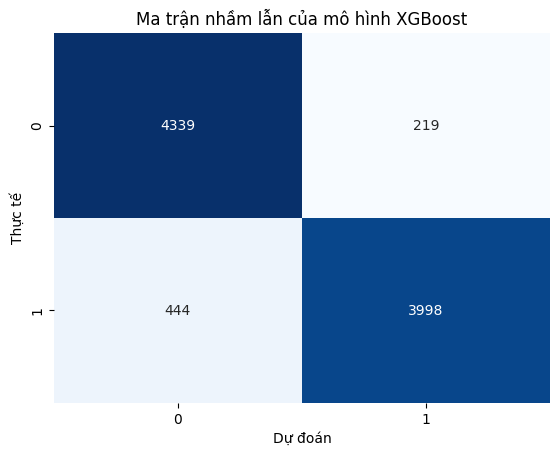

In [166]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("Độ chính xác của mô hình XGBoost: ", accuracy_xgb)
print("Báo cáo phân loại:\n", classification_report(y_test, y_pred_xgb))
conf_matrix_xgb= confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(conf_matrix_xgb, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.title('Ma trận nhầm lẫn của mô hình XGBoost')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

## 5.6. Mô hình MLP

In [167]:
mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        learning_rate_init=1e-3,
        alpha=1e-4,          
        max_iter=500,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42,
        verbose=False
    )
)

mlp.fit(x_train, y_train)
y_pred_mlp = mlp.predict(x_test)

Độ chính xác của mô hình MLP:  0.9172222222222223
Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      4558
           1       0.94      0.89      0.91      4442

    accuracy                           0.92      9000
   macro avg       0.92      0.92      0.92      9000
weighted avg       0.92      0.92      0.92      9000



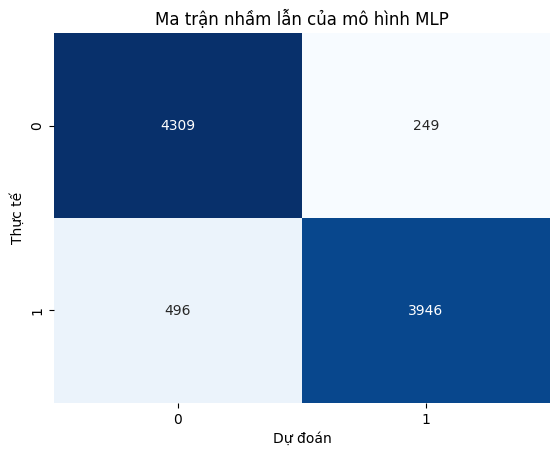

In [168]:
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print("Độ chính xác của mô hình MLP: ", accuracy_mlp)
print("Báo cáo phân loại:\n", classification_report(y_test, y_pred_mlp))
conf_matrix_mlp= confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(conf_matrix_mlp, annot=True, cmap='Blues', fmt='d', cbar=False)

plt.title('Ma trận nhầm lẫn của mô hình MLP')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

# 6. So sánh các mô hình

In [169]:
# Tính precision, recall, f1 cho các mô hình

precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

precision_mlp = precision_score(y_test, y_pred_mlp)
recall_mlp= recall_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)

In [170]:
# Bảng so sánh các chỉ số đánh giá mô hình
performance_summary = pd.DataFrame({
    'Model': [ 'KNN', 'Decision Tree', 'Random Forest', 'Logistic Regression', ' XGBoost', 'MLP'],
    'Accuracy': [ accuracy_knn, accuracy_dt, accuracy_rf, accuracy_lr, accuracy_xgb, accuracy_mlp ],
    'Precision': [ precision_knn, precision_dt, precision_rf, precision_lr, precision_xgb, precision_mlp],
    'Recall': [recall_knn, recall_dt, recall_rf, recall_lr, recall_xgb, recall_mlp],
    'F1-score': [ f1_knn, f1_dt, f1_rf, f1_lr, f1_xgb, f1_mlp]
})

display(performance_summary)

,Model,Accuracy,Precision,Recall,F1-score
0,KNN,0.889889,0.869724,0.913778,0.891206
1,Decision Tree,0.914667,0.933050,0.891040,0.911561
2,Random Forest,0.925778,0.948219,0.898694,0.922792
3,Logistic Regression,0.789556,0.775519,0.807294,0.791088
4,XGBoost,0.926333,0.948067,0.900045,0.923432
5,MLP,0.917222,0.940644,0.888339,0.913743


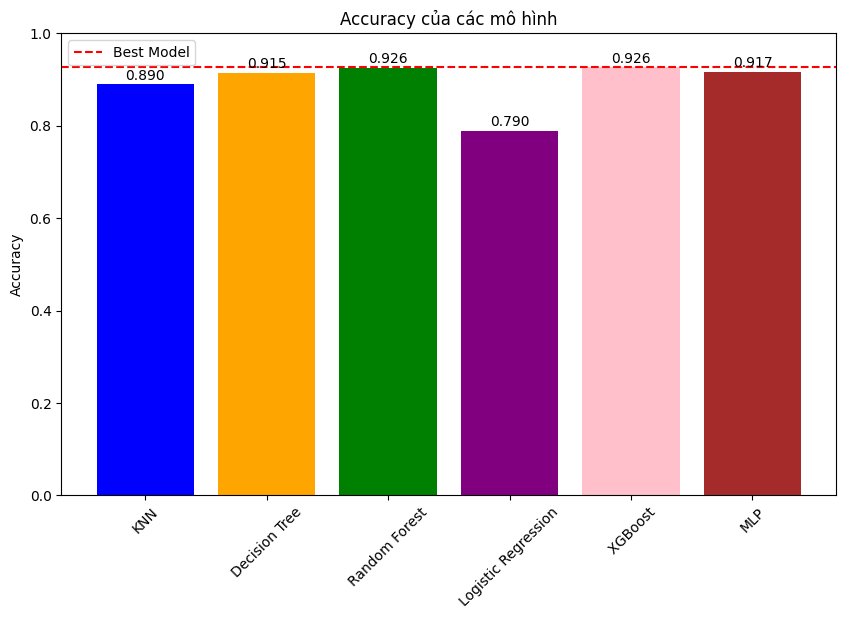

In [171]:
# Sơ đồ so sánh các accuracy giữa các mô hình
accuracies = [accuracy_knn, accuracy_dt, accuracy_rf, accuracy_lr, accuracy_xgb, accuracy_mlp]
models = ['KNN', 'Decision Tree', 'Random Forest', 'Logistic Regression', ' XGBoost', 'MLP']

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'orange', 'green', 'purple', 'pink', 'brown', 'yellow'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Accuracy của các mô hình')
plt.axhline(y=max(accuracies), color='red', linestyle='--', label='Best Model')

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.xticks(rotation=45)
plt.legend()
plt.show()

In [172]:
y_proba_knn = knn.predict_proba(x_test)[:, 1]
y_proba_dt = dt.predict_proba(x_test)[:, 1]
y_proba_rf = rf.predict_proba(x_test)[:, 1]
y_proba_lr = lr.predict_proba(x_test)[:, 1]
y_proba_xgb = xgb.predict_proba(x_test)[:, 1]
y_proba_mlp = mlp.predict_proba(x_test)[:, 1]

In [173]:
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

In [174]:
fpr_knn_micro, tpr_knn_micro, _ = roc_curve(y_test_bin.ravel(), y_proba_knn.ravel())
roc_auc_knn_micro = auc(fpr_knn_micro, tpr_knn_micro)

fpr_dt_micro, tpr_dt_micro, _ = roc_curve(y_test_bin.ravel(), y_proba_dt.ravel())
roc_auc_dt_micro = auc(fpr_dt_micro, tpr_dt_micro)

fpr_rf_micro, tpr_rf_micro, _ = roc_curve(y_test_bin.ravel(), y_proba_rf.ravel())
roc_auc_rf_micro = auc(fpr_rf_micro, tpr_rf_micro)

fpr_lr_micro, tpr_lr_micro, _ = roc_curve(y_test_bin.ravel(), y_proba_lr.ravel())
roc_auc_lr_micro = auc(fpr_lr_micro, tpr_lr_micro)

fpr_xgb_micro, tpr_xgb_micro, _ = roc_curve(y_test_bin.ravel(), y_proba_xgb.ravel())
roc_auc_xgb_micro = auc(fpr_xgb_micro, tpr_xgb_micro)

fpr_mlp_micro, tpr_mlp_micro, _ = roc_curve(y_test_bin.ravel(), y_proba_mlp.ravel())
roc_auc_mlp_micro = auc(fpr_mlp_micro, tpr_mlp_micro)

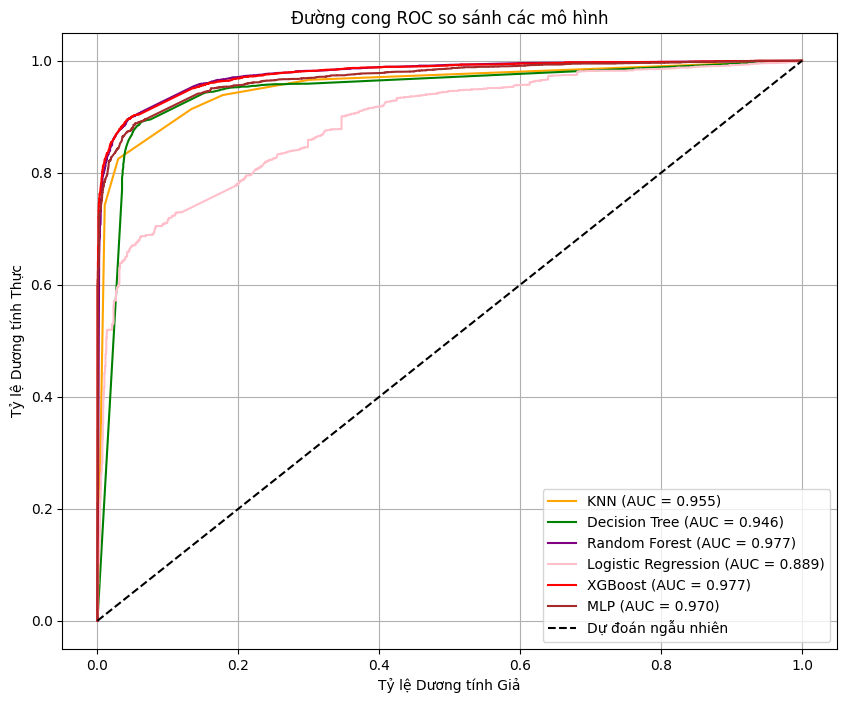

In [175]:
plt.figure(figsize=(10, 8))

colors = ['blue', 'orange', 'green', 'purple', 'pink', 'red', 'brown', 'yellow']

plt.plot(fpr_knn_micro, tpr_knn_micro, label=f'KNN (AUC = {roc_auc_knn_micro:.3f})', color=colors[1])
plt.plot(fpr_dt_micro, tpr_dt_micro, label=f'Decision Tree (AUC = {roc_auc_dt_micro:.3f})', color=colors[2])
plt.plot(fpr_rf_micro, tpr_rf_micro, label=f'Random Forest (AUC = {roc_auc_rf_micro:.3f})', color=colors[3])
plt.plot(fpr_lr_micro, tpr_lr_micro, label=f'Logistic Regression (AUC = {roc_auc_lr_micro:.3f})', color=colors[4])
plt.plot(fpr_xgb_micro, tpr_xgb_micro, label=f'XGBoost (AUC = {roc_auc_xgb_micro:.3f})', color=colors[5])
plt.plot(fpr_mlp_micro, tpr_mlp_micro, label=f'MLP (AUC = {roc_auc_mlp_micro:.3f})', color=colors[6])

plt.plot([0, 1], [0, 1], 'k--', label='Dự đoán ngẫu nhiên')
plt.xlabel('Tỷ lệ Dương tính Giả')
plt.ylabel('Tỷ lệ Dương tính Thực')
plt.title('Đường cong ROC so sánh các mô hình')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Lưu mô hình XGBoost về XGB-URL.plk để phục vụ quá trình dự đoán

In [176]:
import joblib
joblib.dump(xgb, "C:/Users/lengo/Downloads/Python/Do_an/API/XGB.pkl")

['C:/Users/lengo/Downloads/Python/Do_an/API/XGB.pkl']